In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Generating some data

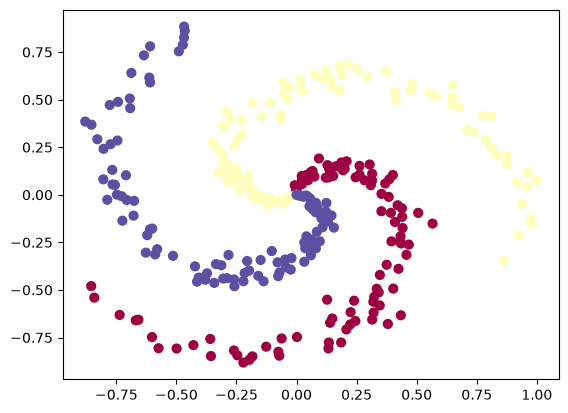

In [42]:
N = 100  # number of datapoints per class
D = 2  # dimensionality
K = 3  # number of classes

X = np.zeros((K * N, D))
y = np.zeros(N * K, dtype=np.uint8)

for j in range(K):
    ix = range(N * j, N * (j + 1))  # iterator over points in the jth class

    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2

    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j  # class to predict

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [43]:
display(X)

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 1.32474341e-03,  1.00137635e-02],
       [-9.84693895e-04,  2.01780078e-02],
       [-2.27286476e-03,  3.02176725e-02],
       [ 2.99332173e-03,  4.02930082e-02],
       [-7.20817398e-03,  4.99880221e-02],
       [ 2.29915220e-02,  5.60757033e-02],
       [ 2.27720356e-02,  6.69397060e-02],
       [ 2.29818365e-02,  7.74711631e-02],
       [ 4.80738667e-02,  7.71580595e-02],
       [ 2.17718826e-02,  9.86358233e-02],
       [ 4.05177004e-02,  1.03460113e-01],
       [ 7.41386325e-02,  9.58949503e-02],
       [ 5.78000624e-02,  1.17907978e-01],
       [ 6.65642255e-02,  1.24768439e-01],
       [ 1.21916652e-01,  8.99620536e-02],
       [ 1.33293296e-01,  9.13930025e-02],
       [ 1.37323603e-01,  1.03097115e-01],
       [ 1.52383710e-01,  9.91819340e-02],
       [ 1.35990684e-01,  1.35423448e-01],
       [ 1.28819213e-01,  1.55620604e-01],
       [ 9.31532349e-02,  1.90572515e-01],
       [ 1.64172230e-01,  1.49767136e-01],
       [ 1.

In [44]:
display(y)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], d

# Training Softmax Linear Classifier

Softmax classifier is a supervised learning algorithm used for multi-class classification task. Softmax function is given as

$$
\sigma : \R^K \to (0, 1)^K  \\
\sigma(\bold{z})_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}
$$

where $K > 1$

In [45]:
# np.random.randn returns samples from normal distribution
W = 0.01 * np.random.randn(D, K)  # D = 2 (dimensiona.lity), K = 3 (nummer of classes)
b = np.zeros((1, K))

In [46]:
# Because X and W are matrices np.dot <=> @ multiplication
# scores = np.dot(X, W) + b
scores = X @ W + b

## Compute the loss 

To compute the loss we need a loss function that is a differentiable object that quantifies our unhappiness with the computed class scores.

Correct class $\to$ higher score, not correct $\to$ lower score. Loss should be low when classes are correct and high when not. When $\cal{f}$ is the array of class scores for a single example (in our case array of 3 numbers) then Softmax classifier computes the loss as

$$
L_i = -\log \left( \frac{e^{f_{y_i}}}{\sum_{j}{e^{f_j}}}\right)
$$

where $y_i$ is the correct class for sample $i$. Expression inside the log is the normalized probability of the correct class. This quantity is always between 0 and 1. When normalized probability is very small loss will go towards infinity. When the probability is high ($\to 1$) then loss approaches $0$. 

Then full Softmax classifier loss is defined as average cross-entropy loss over the training examples and the regularization 

$$
L = \frac{1}{N} \sum_{i}{L_i} + \frac{1}{2} \lambda \sum_{k} \sum_{l} W_{k,l}^2
$$

where $\frac{1}{N} \sum_{i}{L_i}$ is the "data loss" (averaged loss for all samples) and $\frac{1}{2} \lambda \sum_{k} \sum_{l} W_{k,l}^2$ is the regularization expression, with $\lambda$ controlling the regularization strength. So we want small data loss, and small numbers as parameters. 

In [47]:
exp_scores = np.exp(scores)
probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

Now `probs` is an array of size `[300 x 3]`, where each row now contains the normalized class probabilities

In [48]:
num_examples = X.shape[0]
correct_logprobs = -np.log(probs[range(num_examples), y])

Now `correct_logprobs` is a 1D array of losses for each sample.

In [49]:
reg = 1  # Regularization strength (lambda)

data_loss = np.sum(correct_logprobs) / num_examples
reg_loss = 0.5 * reg * np.sum(W * W)
loss = data_loss + reg_loss

loss

np.float64(1.1010701866061843)

## Computing Analytic Gradient with Backpropagation

We have the loss, now we need to minimize it $\to$ gradient descent.

1) Start with random parameters 
2) Evaluate the gradient of the loss w.r.t parameters to know how to change them to decrease it

Let $p$ be the vector of normalized probabilities, then

$$
p_k = \frac{e^{f_k}}{\sum_{j}{e^{f_j}}} \space \space \space \space \space \space \space \space \space \space \space \space  L_i = - \log (p_{y_i})
$$

Now we want to derive the gradient $\frac{\partial L_i}{\partial f_k}$ to understand how the computed scores inside f should change to decrease the loss $L_i$. With some help of chainrule it can be shown that

$$
\frac{\partial L_i}{\partial f_k} = p_k - \bold{1} (y_i = k)
$$

<p align="center">
    <img src="solution.jpg" width="300" height="200">
</p>


In [50]:
dscores = probs  # probs stores probabilities of all classes for each example
dscores[range(num_examples), y] -= 1
dscores /= num_examples

In [51]:
dW = X.T @ dscores
db = np.sum(dscores, axis=0, keepdims=True)
dW += reg * W

In [52]:
step_size = 0.01

W += -step_size * dW
b += -step_size * db

## Final training loop

In [53]:
"""
N - number of samples
D - number of dimensions 
K - number of classes 
"""

# Initialize parameters randomly
W = 0.01 * np.random.randn(D, K)
b = np.zeros((1, K))

# some hyperparameters
step_size = 1e-0
reg = 1e-3

# gradient descent loop
num_examples = X.shape[0]

for i in range(200):
    # evaluate class scores
    scores = X @ W + b  # [N x K]

    # compute class probabilities
    exp_scores = np.exp(scores)  # [N x K]

    # this computes normalized probability of each class for each sample
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # [N x K]

    # compute the loss
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs) / num_examples
    reg_loss = 0.5 * reg * np.sum(W * W)
    loss = data_loss + reg_loss

    if i % 10 == 0:
        print(f"iteration {i} loss {loss}")

    # compute the gradient on scores
    dscores = probs
    dscores[range(num_examples), y] -= 1
    dscores /= num_examples

    # backpropagate
    dW = X.T @ dscores
    db = np.sum(dscores, axis=0, keepdims=True)

    # regularization gradient
    dW += reg * W

    # perform a parameter update
    W += -step_size * dW
    b += -step_size * db

iteration 0 loss 1.0970244408895344
iteration 10 loss 0.9066931449231702
iteration 20 loss 0.8361457653189655
iteration 30 loss 0.804349151380624
iteration 40 loss 0.7879682542160669
iteration 50 loss 0.7787529189536047
iteration 60 loss 0.773247038068508
iteration 70 loss 0.769813046720789
iteration 80 loss 0.7676021308847695
iteration 90 loss 0.766143818365986
iteration 100 loss 0.7651636317420466
iteration 110 loss 0.7644949022733535
iteration 120 loss 0.7640331550709691
iteration 130 loss 0.7637111997451067
iteration 140 loss 0.763484910724233
iteration 150 loss 0.7633248058521457
iteration 160 loss 0.7632109030452885
iteration 170 loss 0.7631294963408205
iteration 180 loss 0.7630710899639146
iteration 190 loss 0.7630290492831628


In [54]:
scores = X @ W + b
predicted_class = np.argmax(scores, axis=1)
print(f"training accuracy: {np.mean(predicted_class == y):.2f}")

training accuracy: 0.52


We can see that linear classifier _fails_ to learn spiral dataset (which has by nature nonlinear behaviour)

# Training a Neural Network

In [55]:
# Initialize random parameters

h = 100  # size of hidden layer

W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))

W2 = 0.01 * np.random.randn(h, K)
b2 = np.zeros((1, K))

In [56]:
hidden_layer = np.maximum(0, X @ W + b)  # forward pass + ReLU
scores = np.dot(hidden_layer, W2) + b2

In [57]:
# backpropagate the gradient to the parameters
# first backpropagate into parameters W2 and b2

dW2 = hidden_layer.T @ dscores
db2 = np.sum(dscores, axis=0, keepdims=True)

In [58]:
dhidden = dscores @ W2.T
dhidden[hidden_layer <= 0] = 0  # because of ReLU

dW = X.T @ dhidden
db = np.sum(dhidden, axis=0, keepdims=True)

In [60]:
# initialize parameters randomly
h = 100  # size of hidden layer
W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))
W2 = 0.01 * np.random.randn(h, K)
b2 = np.zeros((1, K))

# hyperparameters
step_size = 1e-0
reg = 1e-3

num_examples = X.shape[0]
for i in range(10000):
    # evaluate class scores, [N x K]

    hidden_layer = np.maximum(0, X @ W + b)  # remember about ReLU
    scores = hidden_layer @ W2 + b2

    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # [N x K]

    # compute the loss: average cross-entropy and regularization
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs) / num_examples
    reg_loss = 0.5 * reg * np.sum(W * W) + 0.5 * reg * np.sum(W2 * W2)
    loss = data_loss + reg_loss

    if i % 1000 == 0:
        print(f"iteration {i} loss {loss}")

    # compute the gradient on scores
    dscores = probs
    dscores[range(num_examples), y] -= 1
    dscores /= num_examples

    # backpropagate

    dW2 = hidden_layer.T @ dscores
    db2 = np.sum(dscores, axis=0, keepdims=True)

    dhidden = dscores @ W2.T
    dhidden[hidden_layer <= 0] = 0

    dW = X.T @ dhidden
    db = np.sum(dhidden, axis=0, keepdims=True)

    dW2 += reg * W2
    dW += reg * W

    # parameter update
    W += -step_size * dW
    b += -step_size * db
    W2 += -step_size * dW2
    b2 += -step_size * db2

iteration 0 loss 1.0987191603293782
iteration 1000 loss 0.3002521733902854
iteration 2000 loss 0.2768775359442823
iteration 3000 loss 0.26077704478382063
iteration 4000 loss 0.24828015523859706
iteration 5000 loss 0.2457571382605508
iteration 6000 loss 0.244668349911853
iteration 7000 loss 0.24412957919961698
iteration 8000 loss 0.2437524319577847
iteration 9000 loss 0.2435519610367846


In [61]:
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
predicted_class = np.argmax(scores, axis=1)

print(f"training accuracy: {np.mean(predicted_class == y):.2f}")

training accuracy: 0.99
